<a href="https://colab.research.google.com/github/mafudsetiono/Retail-Sales-Analytics/blob/main/Retail_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Business Understanding
**Latar Belakang**

Dataset ini merepresentasikan operasi sebuah perusahaan retail yang memiliki beberapa toko, produk, pelanggan, dan aktivitas penjualan.

Perusahaan ingin memahami kinerja bisnis mereka dari berbagai aspek seperti penjualan, pelanggan, produk, dan operasional.

Analisis ini bertujuan membantu manajemen untuk:

- memahami performa penjualan

- mengidentifikasi produk paling laris

- mengetahui performa toko

- mengevaluasi strategi marketing

- meningkatkan kepuasan pelanggan

**Tujuan Analisis**

Menganalisis performa bisnis retail untuk mengidentifikasi tren penjualan, produk paling menguntungkan, perilaku pelanggan, serta performa toko guna mendukung pengambilan keputusan bisnis yang lebih baik.

#Load Dataset

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette("viridis")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path
path = "/content/drive/MyDrive/Portofolio Data Analyst/Dataset/"

Mounted at /content/drive


In [ ]:
sales = pd.read_csv(path + "Vendas.csv")
products = pd.read_csv(path + "Produtos.csv")
customers = pd.read_csv(path + "Clientes.csv")
stores = pd.read_csv(path + "Lojas.csv")

#Data Cleansing

##Translate Kolom

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Venda_ID        20000 non-null  int64  
 1   Loja_ID         20000 non-null  int64  
 2   Produto_ID      20000 non-null  int64  
 3   Cliente_ID      20000 non-null  int64  
 4   Colaborador_ID  20000 non-null  int64  
 5   Quantidade      20000 non-null  int64  
 6   Preço Unitário  20000 non-null  float64
 7   Data da Venda   20000 non-null  object 
 8   Canal de Venda  20000 non-null  object 
dtypes: float64(1), int64(6), object(2)
memory usage: 1.4+ MB


In [ ]:
sales = sales.rename(columns={
    "Venda_ID": "sale_id",
    "Loja_ID": "store_id",
    "Produto_ID": "product_id",
    "Cliente_ID": "customer_id",
    "Colaborador_ID": "employee_id",
    "Quantidade": "quantity",
    "Preço Unitário": "unit_price",
    "Data da Venda": "sale_date",
    "Canal de Venda": "sales_channel"
})

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Produto_ID       1000 non-null   int64  
 1   Nome             1000 non-null   object 
 2   Categoria        1000 non-null   object 
 3   Cor              1000 non-null   object 
 4   Descrição        1000 non-null   object 
 5   Tamanho          1000 non-null   object 
 6   Preço            1000 non-null   float64
 7   Custo_Aquisição  1000 non-null   float64
 8   Imagem           1000 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 70.4+ KB


In [ ]:
products = products.rename(columns={
    "Produto_ID": "product_id",
    "Nome": "product_name",
    "Categoria": "category",
    "Cor": "color",
    "Descrição": "description",
    "Tamanho": "size",
    "Preço": "price",
    "Custo_Aquisição": "acquisition_cost",
    "Imagem": "image"
})

In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cliente_ID        1000 non-null   int64  
 1   Nome              1000 non-null   object 
 2   Idade             1000 non-null   int64  
 3   Género            1000 non-null   object 
 4   Cidade            1000 non-null   object 
 5   Canal de Compra   1000 non-null   object 
 6   Total de Compras  1000 non-null   float64
 7   Imagem            1000 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 62.6+ KB


In [ ]:
customers = customers.rename(columns={
    "Cliente_ID": "customer_id",
    "Nome": "customer_name",
    "Idade": "age",
    "Género": "gender",
    "Cidade": "customer_city",
    "Canal de Compra": "purchase_channel",
    "Total de Compras": "total_purchases",
    "Imagem": "image"
})

In [ ]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Loja_ID  5 non-null      int64 
 1   Nome     5 non-null      object
 2   Região   5 non-null      object
 3   Cidade   5 non-null      object
 4   Tipo     5 non-null      object
dtypes: int64(1), object(4)
memory usage: 332.0+ bytes


In [ ]:
stores = stores.rename(columns={
    "Loja_ID": "store_id",
    "Nome": "store_name",
    "Região": "region",
    "Cidade": "store_city",
    "Tipo": "store_type"
})

##Merge Dataset

In [ ]:
df = sales.merge(products, on="product_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(stores, on="store_id", how="left")

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
19995,False
19996,False
19997,False
19998,False


In [ ]:
#Cek tanggal trx
display(
    df["sale_date"].min(),
    df["sale_date"].max()
  )

Timestamp('2014-01-01 01:14:52')

Timestamp('2024-12-31 15:53:01')

#Feature Engineering

In [ ]:
df["revenue"] = df["quantity"] * df["unit_price"]

In [ ]:
df["profit"] = (df["unit_price"] - df["acquisition_cost"]) * df["quantity"]

In [ ]:
df[df["profit"] < 0]

,sale_id,store_id,product_id,customer_id,employee_id,quantity,unit_price,sale_date,sales_channel,product_name,...,customer_city,purchase_channel,total_purchases,image_y,store_name,region,store_city,store_type,revenue,profit
16,17,1,207,975,200,87,23.34,2017-03-10 04:22:37,Física,Dolorum,...,Tavira,Online,197.25,https://randomuser.me/api/portraits/women/8.jpg,Loja Borges S.A.,Centro,Leiria,Online,2030.58,-172.26
81,82,2,165,446,177,41,38.88,2015-03-13 21:32:09,Física,Ipsam,...,Vila Real de Santo António,Física,321.62,https://randomuser.me/api/portraits/men/37.jpg,Loja Ramos Lda.,Algarve,Lagoa,Física,1594.08,-384.99
146,147,1,33,524,448,87,37.11,2024-02-12 17:52:41,Online,Ea,...,Almodôvar,Online,938.58,https://randomuser.me/api/portraits/women/64.jpg,Loja Borges S.A.,Centro,Leiria,Online,3228.57,-1055.31
154,155,3,916,444,355,29,8.74,2016-04-15 00:12:56,Física,Adipisci,...,Vila do Conde,Online,885.40,https://randomuser.me/api/portraits/women/47.jpg,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Física,253.46,-360.47
186,187,2,416,533,95,34,45.99,2024-03-22 22:53:22,Física,Animi,...,Penamacor,Física,313.32,https://randomuser.me/api/portraits/women/78.jpg,Loja Ramos Lda.,Algarve,Lagoa,Física,1563.66,-21.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19844,19845,2,456,693,18,6,10.19,2023-07-20 12:14:14,Física,Possimus,...,Portalegre,Física,521.87,https://randomuser.me/api/portraits/women/73.jpg,Loja Ramos Lda.,Algarve,Lagoa,Física,61.14,-34.14
19913,19914,2,358,123,81,99,33.02,2023-08-11 19:30:41,Física,Doloremque,...,Albufeira,Online,270.41,https://randomuser.me/api/portraits/women/12.jpg,Loja Ramos Lda.,Algarve,Lagoa,Física,3268.98,-518.76
19937,19938,4,150,84,72,68,12.74,2019-03-20 22:13:34,Online,Sit,...,Estremoz,Online,693.27,https://randomuser.me/api/portraits/women/92.jpg,Loja Maia Loureiro S.A.,Centro,Castelo Branco,Física,866.32,-269.28
19964,19965,1,873,502,456,79,20.87,2020-09-26 14:00:41,Física,Vitae,...,Barrancos,Física,775.15,https://randomuser.me/api/portraits/women/9.jpg,Loja Borges S.A.,Centro,Leiria,Online,1648.73,-1404.62


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           20000 non-null  int64  
 1   store_id          20000 non-null  int64  
 2   product_id        20000 non-null  int64  
 3   customer_id       20000 non-null  int64  
 4   employee_id       20000 non-null  int64  
 5   quantity          20000 non-null  int64  
 6   unit_price        20000 non-null  float64
 7   sale_date         20000 non-null  object 
 8   sales_channel     20000 non-null  object 
 9   product_name      20000 non-null  object 
 10  category          20000 non-null  object 
 11  color             20000 non-null  object 
 12  description       20000 non-null  object 
 13  size              20000 non-null  object 
 14  price             20000 non-null  float64
 15  acquisition_cost  20000 non-null  float64
 16  image_x           20000 non-null  object

In [ ]:
# Ubah tipe data
df["sale_date"] = pd.to_datetime(df["sale_date"])

In [ ]:
df["year"] = df["sale_date"].dt.year
df["month"] = df["sale_date"].dt.month
df["day"] = df["sale_date"].dt.day
df["month_name"] = df["sale_date"].dt.month_name()

In [ ]:
df[["unit_price","acquisition_cost"]].describe()

,unit_price,acquisition_cost
count,20000.000000,20000.000000
mean,501.006653,30.154807
std,288.182446,11.561283
min,2.070000,10.020000
25%,253.677500,19.950000
50%,503.465000,30.470000
75%,750.495000,40.020000
max,999.920000,49.970000


In [ ]:
# Drop kolom yang tidak digunakan
df = df.drop(columns=[
    "image_x", # Ini hanya URL gambar produk.
    "image_y", # Ini hanya URL gambar customer.
    "description", # Tidak dipakai di EDA.
    "employee_id" # Tidak digunakan
])

In [ ]:
df.head()

,sale_id,store_id,product_id,customer_id,quantity,unit_price,sale_date,sales_channel,product_name,category,...,store_name,region,store_city,store_type,revenue,profit,year,month,day,month_name
0,1,1,259,41,30,175.88,2020-04-19 13:51:40,Online,Harum,Roupas,...,Loja Borges S.A.,Centro,Leiria,Online,5276.40,4239.90,2020,4,19,April
1,2,1,898,308,90,83.19,2016-05-16 04:52:08,Física,Eius,Calçado,...,Loja Borges S.A.,Centro,Leiria,Online,7487.10,6278.40,2016,5,16,May
2,3,3,357,910,88,682.42,2018-11-30 17:45:41,Online,Quasi,Roupas,...,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Física,60052.96,56268.08,2018,11,30,November
3,4,1,490,914,63,365.50,2024-12-31 15:53:01,Online,Voluptatibus,Roupas,...,Loja Borges S.A.,Centro,Leiria,Online,23026.50,21150.36,2024,12,31,December
4,5,4,341,92,47,182.52,2019-03-21 17:00:00,Física,Suscipit,Roupas,...,Loja Maia Loureiro S.A.,Centro,Castelo Branco,Física,8578.44,7333.41,2019,3,21,March


Berdasarkan nama wilayah seperti Alentejo, dataset ini kemungkinan merepresentasikan bisnis retail di Portugal.

#EDA

##Total Revenue and Profit

In [ ]:
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()

print("Total Revenue:", round(total_revenue,2))
print("Total Profit:", round(total_profit,2))

Total Revenue: 505159249.56
Total Profit: 474743291.13


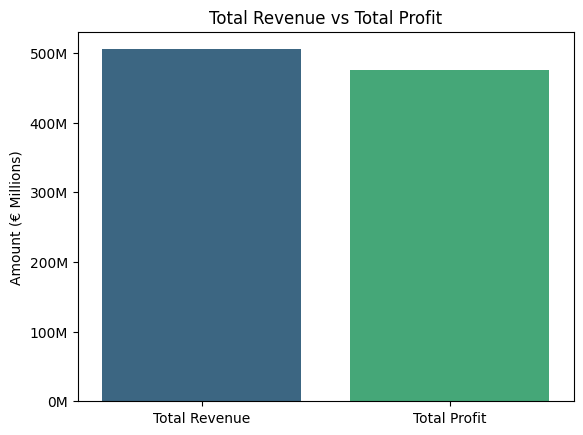

In [ ]:
import matplotlib.ticker as ticker

# Summary
summary = pd.DataFrame({
    'metric': ['Total Revenue', 'Total Profit'],
    'value': [total_revenue, total_profit]
})

ax = sns.barplot(data=summary, x="metric", y="value", palette="viridis", hue="metric")

# Formatting ke jutaan (Millions)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.title("Total Revenue vs Total Profit")
plt.xlabel("")
plt.ylabel("Amount (€ Millions)")
plt.show()

### Insight

Grafik menunjukkan bahwa total revenue perusahaan mencapai sekitar (EUR)500 juta, dengan total profit sekitar (EUR)470 juta. Selisih yang relatif kecil antara revenue dan profit menunjukkan bahwa perusahaan memiliki margin keuntungan yang sangat tinggi, yang mengindikasikan bahwa biaya akuisisi produk relatif rendah dibandingkan harga jualnya. Hal ini menandakan bahwa bisnis memiliki profitabilitas yang kuat dalam aktivitas penjualannya.

##Revenue and Profit by Region

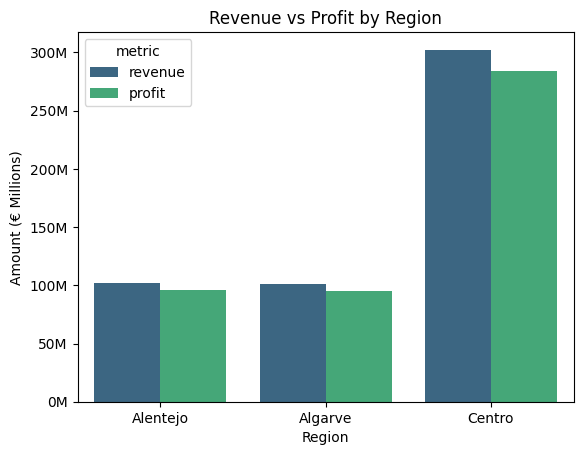

In [ ]:
# Agregasi
region_sales = df.groupby("region")[["revenue","profit"]].sum().reset_index()
region_sales = region_sales.melt(id_vars="region", var_name="metric", value_name="value")

ax = sns.barplot(data=region_sales, x="region", y="value", hue="metric", palette="viridis")

# Formating
import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
plt.title("Revenue vs Profit by Region")
plt.ylabel("Amount (€ Millions)")
plt.xlabel("Region")
plt.show()

###Insight

Grafik menunjukkan bahwa region Centro memiliki performa penjualan paling tinggi, dengan total revenue sekitar 300 juta dan profit sekitar 280 juta, jauh melampaui region lainnya. Sementara itu, Alentejo dan Algarve memiliki performa yang relatif mirip, dengan revenue dan profit yang berada di kisaran 100 juta. Hal ini menunjukkan bahwa Centro merupakan kontributor utama terhadap pendapatan perusahaan, sehingga wilayah ini berpotensi menjadi fokus utama dalam strategi bisnis, seperti peningkatan stok, ekspansi toko, atau aktivitas pemasaran untuk mempertahankan dan meningkatkan performa penjualan.

## Sales Trend Over Time

In [ ]:
#Agregasi
monthly_revenue = df.groupby("month_name")["revenue"].sum().reset_index()

In [ ]:
order = ["January","February","March","April","May","June",
         "July","August","September","October","November","December"]

monthly_revenue["month_name"] = pd.Categorical(
    monthly_revenue["month_name"], categories=order, ordered=True
)

monthly_revenue = monthly_revenue.sort_values("month_name")

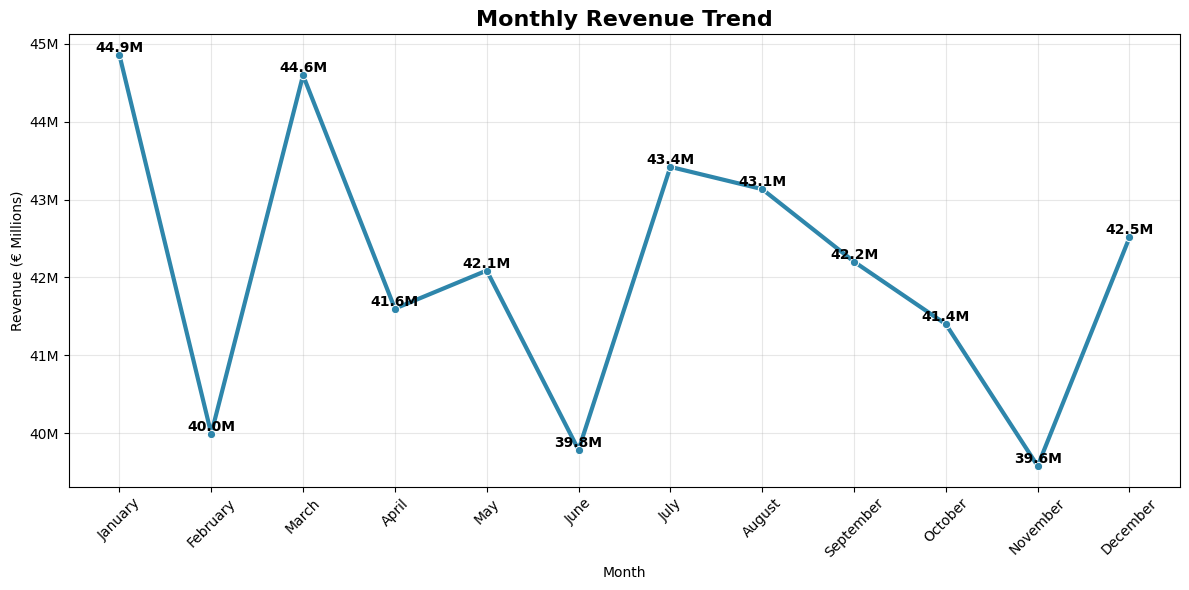

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=monthly_revenue,
    x="month_name",
    y="revenue",
    marker="o",
    linewidth=3,
    color="#2E86AB"
)

plt.title("Monthly Revenue Trend", fontsize=16, weight="bold")

plt.xlabel("Month")
plt.ylabel("Revenue (€ Millions)")
plt.xticks(rotation=45)

# Format axis ke Millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Tambahkan label angka di atas titik
for x, y in zip(monthly_revenue["month_name"], monthly_revenue["revenue"]):
    plt.text(x, y, f'{y/1e6:.1f}M', ha='center', va='bottom', fontsize=10, weight='bold')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Insight

Grafik menunjukkan bahwa revenue bulanan perusahaan relatif stabil sepanjang tahun, dengan kisaran sekitar 39 juta hingga 45 juta euro. Revenue tertinggi terjadi pada Januari (44.9M) dan Maret (44.6M), sementara revenue terendah terjadi pada November (39.6M). Secara umum terlihat adanya fluktuasi penjualan antar bulan, dengan peningkatan kembali pada pertengahan tahun (Juli–Agustus) setelah penurunan di bulan Juni. Pola ini menunjukkan adanya periode dengan permintaan yang lebih tinggi di awal dan pertengahan tahun, yang dapat dimanfaatkan perusahaan untuk mengoptimalkan strategi pemasaran, promosi, serta pengelolaan stok pada periode dengan potensi penjualan yang lebih kuat.

##Top 10 products by revenue

In [ ]:
top_products = (
    df.groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

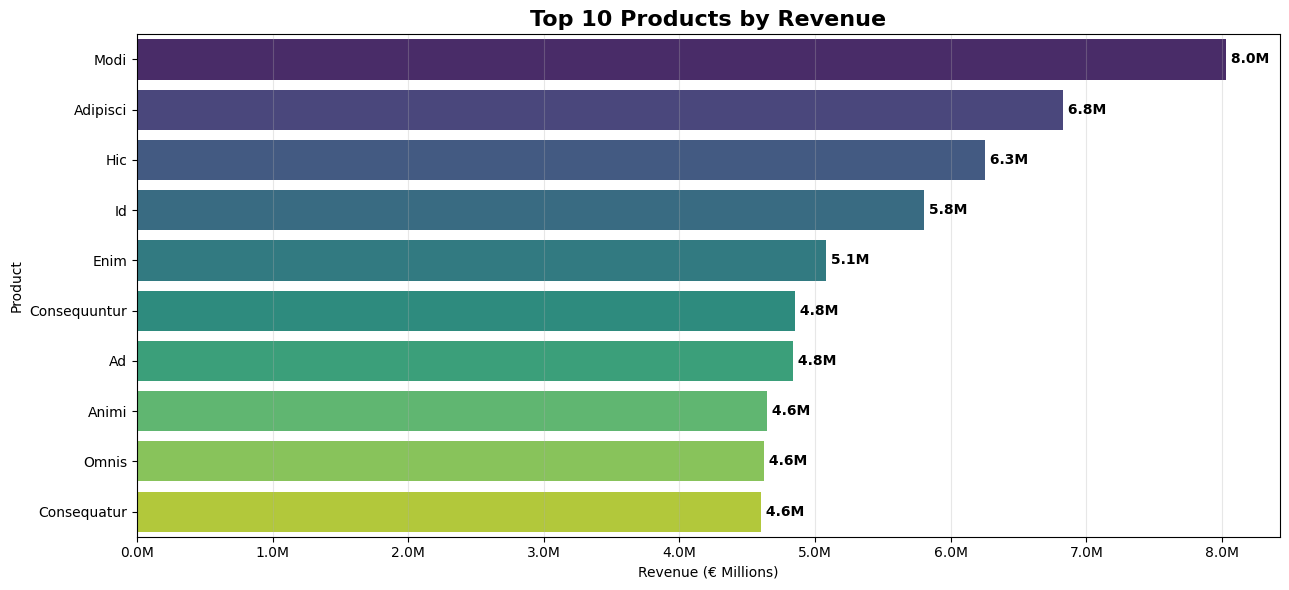

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(13,6))

sns.barplot(
    data=top_products,
    x="revenue",
    y="product_name",
    palette="viridis",
    hue="product_name",
    legend=False
)

plt.title("Top 10 Products by Revenue", fontsize=16, weight="bold")
plt.xlabel("Revenue (€ Millions)")
plt.ylabel("Product")

# format ke Millions
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# label nilai di bar
for index, value in enumerate(top_products["revenue"]):
    plt.text(value, index, f' {value/1e6:.1f}M', va="center", weight='bold')

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

###Insight

Grafik menunjukkan bahwa produk "Modi" merupakan kontributor revenue tertinggi, dengan total pendapatan sekitar 8 juta euro, diikuti oleh Adipisci (6.8M) dan Hic (6.3M). Perbedaan yang cukup signifikan antara produk peringkat pertama dan produk lainnya menunjukkan bahwa beberapa produk memiliki kontribusi yang lebih dominan terhadap total pendapatan perusahaan. Hal ini mengindikasikan bahwa produk-produk dengan performa tinggi tersebut berpotensi menjadi produk unggulan, sehingga perusahaan dapat mempertimbangkan strategi seperti peningkatan stok, promosi, atau pengembangan produk serupa untuk memaksimalkan penjualan.

## Revenue by Category

In [ ]:
category_revenue = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

/tmp/ipykernel_256/1636701668.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


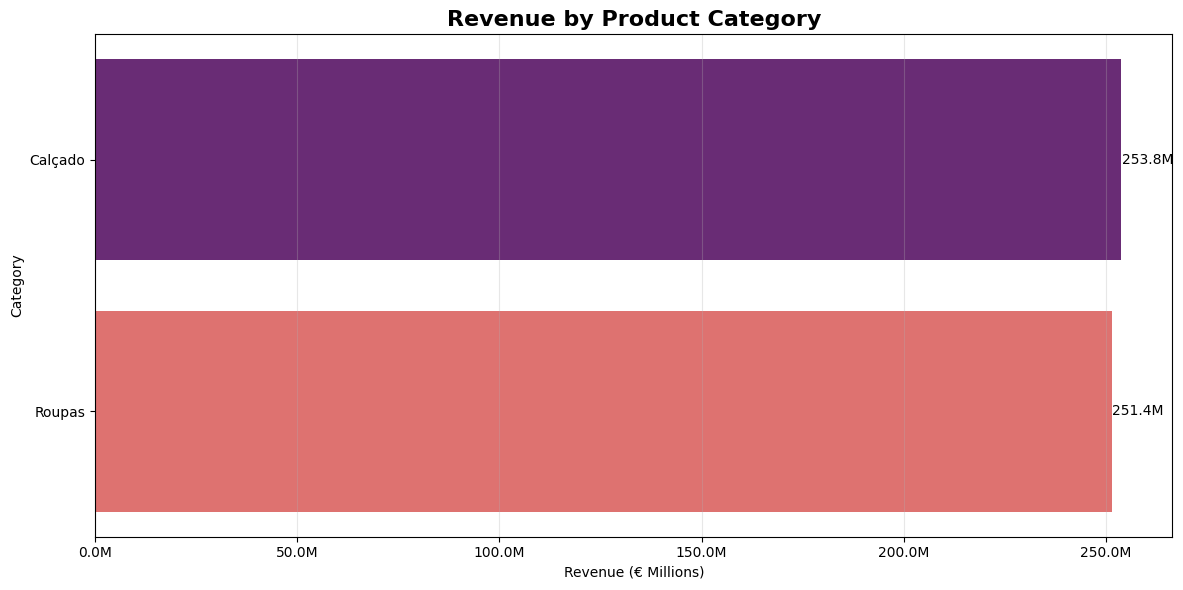

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

sns.barplot(
    data=category_revenue,
    x="revenue",
    y="category",
    palette="magma"
)

plt.title("Revenue by Product Category", fontsize=16, weight="bold")
plt.xlabel("Revenue (€ Millions)")
plt.ylabel("Category")

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

for index, value in enumerate(category_revenue["revenue"]):
    plt.text(value + 100000, index, f'{value/1e6:.1f}M', va="center")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

Grafik menunjukkan bahwa kategori Calcado (sepatu) menghasilkan revenue tertinggi dengan sekitar 253.8 juta euro, sedikit lebih tinggi dibandingkan kategori Roupas (pakaian) yang menghasilkan sekitar 251.4 juta euro. Meskipun perbedaannya tidak terlalu besar, hasil ini menunjukkan bahwa produk sepatu memiliki kontribusi penjualan yang sedikit lebih tinggi dibandingkan pakaian. Hal ini mengindikasikan bahwa permintaan terhadap produk sepatu sedikit lebih kuat di pasar, sehingga perusahaan dapat mempertimbangkan strategi seperti meningkatkan stok atau promosi pada kategori ini untuk memaksimalkan pendapatan.

##Revenue by Sales Channel

In [ ]:
df["sales_channel"] = df["sales_channel"].replace({
    "Física": "Offline Store",
    "Online": "Online Store"
})
channel_revenue = (
    df.groupby("sales_channel")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

/tmp/ipykernel_256/4068587705.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


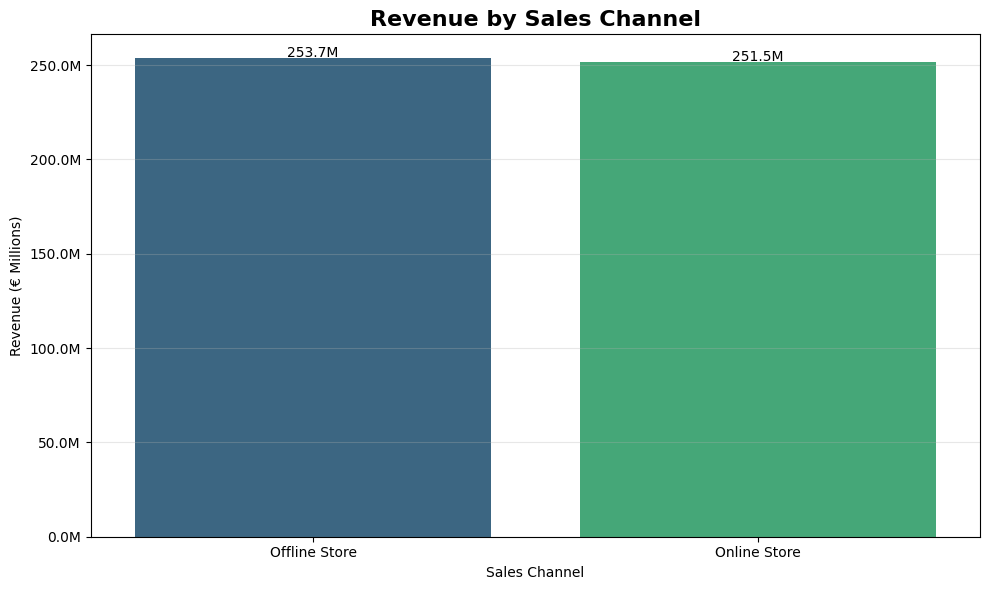

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))

sns.barplot(
    data=channel_revenue,
    x="sales_channel",
    y="revenue",
    palette="viridis"
)

plt.title("Revenue by Sales Channel", fontsize=16, weight="bold")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue (€ Millions)")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

for index, value in enumerate(channel_revenue["revenue"]):
    plt.text(index, value + 500000, f'{value/1e6:.1f}M', ha="center")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

Grafik menunjukkan bahwa penjualan melalui offline Store menghasilkan revenue sekitar 253.7 juta euro, sedikit lebih tinggi dibandingkan penjualan online yang menghasilkan sekitar 251.5 juta euro. Perbedaan yang sangat kecil antara kedua channel ini menunjukkan bahwa perusahaan memiliki performa penjualan yang seimbang antara channel offline dan online. Hal ini mengindikasikan bahwa strategi omnichannel perusahaan berjalan dengan baik, di mana pelanggan melakukan pembelian baik melalui toko fisik maupun platform online dengan kontribusi yang hampir sama terhadap total revenue.

##Age Distribution

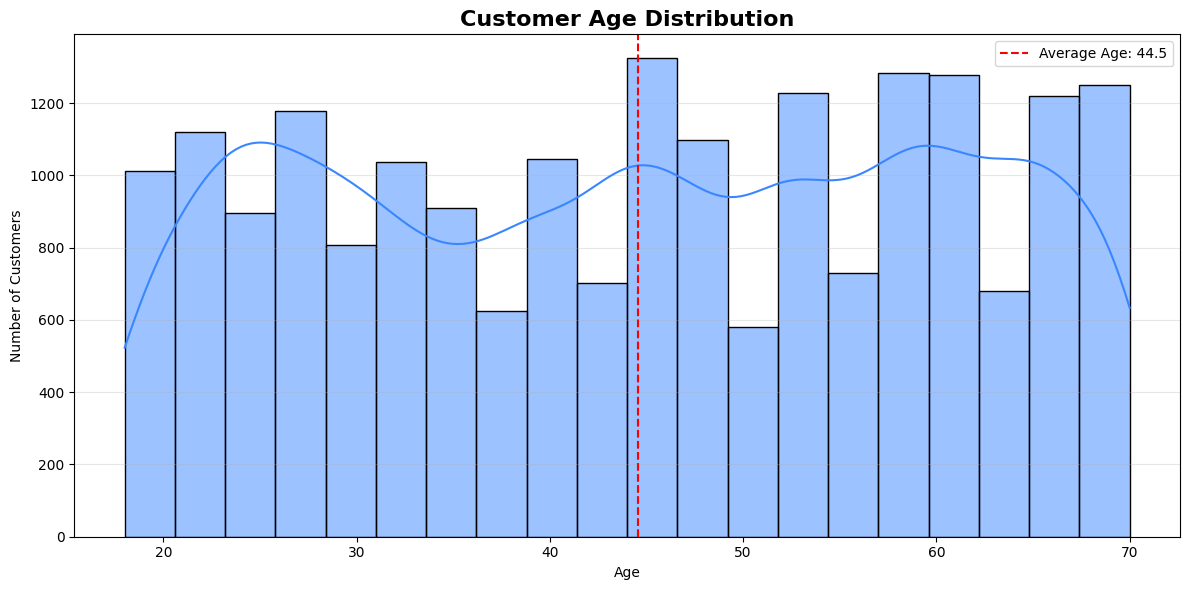

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["age"],
    bins=20,
    kde=True,
    color="#3A86FF"
)

mean_age = df["age"].mean()

plt.axvline(mean_age, color="red", linestyle="--", label=f"Average Age: {mean_age:.1f}")

plt.title("Customer Age Distribution", fontsize=16, weight="bold")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

Distribusi usia pelanggan menunjukkan bahwa pelanggan retail berasal dari rentang usia yang cukup luas, yaitu sekitar 18 hingga 70 tahun, dengan rata-rata usia sekitar 44.5 tahun. Hal ini menunjukkan bahwa mayoritas pelanggan berada pada kelompok usia dewasa dan usia produktif, yang umumnya memiliki daya beli yang stabil. Sebaran usia yang cukup merata juga mengindikasikan bahwa produk yang dijual oleh perusahaan mampu menjangkau berbagai segmen usia, sehingga strategi pemasaran dapat difokuskan pada segmen usia dewasa sebagai target utama, sambil tetap mempertahankan daya tarik produk bagi kelompok lainnya.

##Revenue by Gender

In [ ]:
revenue_gender = df.groupby("gender")["revenue"].sum().reset_index()
revenue_gender.columns = ["gender", "revenue"]

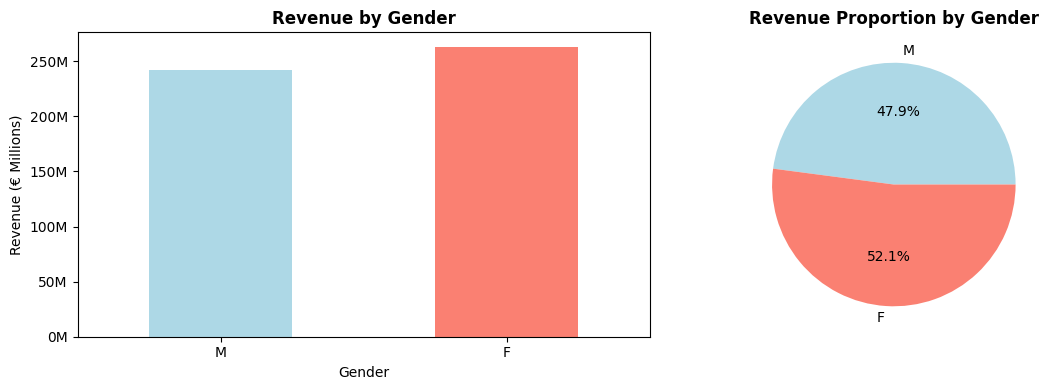

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Bar chart
revenue_gender.plot(
    kind="bar",
    x="gender",
    y="revenue",
    ax=axes[0],
    color=["lightblue", "salmon"],
    legend=False
)

axes[0].set_title("Revenue by Gender", fontweight="bold")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Revenue (€)")
axes[0].set_xticklabels(["M","F"], rotation=0)

# Pie chart
axes[1].pie(
    revenue_gender["revenue"],
    labels=["M","F"],
    autopct="%1.1f%%",
    colors=["lightblue","salmon"]
)
axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

axes[0].set_ylabel("Revenue (€ Millions)")
axes[1].set_title("Revenue Proportion by Gender", fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
df['gender'].value_counts()

,count
gender,
M,10508
F,9492


### Insight

Revenue berdasarkan gender menunjukkan bahwa pelanggan laki-laki menghasilkan kontribusi revenue yang sedikit lebih tinggi dibandingkan pelanggan perempuan, dengan proporsi sekitar 52.1% berbanding 47.9%. Meskipun terdapat perbedaan, selisihnya relatif kecil sehingga menunjukkan bahwa produk yang dijual perusahaan memiliki daya tarik yang cukup seimbang bagi kedua gender. Hal ini mengindikasikan bahwa perusahaan berhasil menjangkau pasar yang luas tanpa terlalu bergantung pada satu segmen gender tertentu.

## Store Performance

In [ ]:
store_revenue = (
    df.groupby("store_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

/tmp/ipykernel_256/1400984239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


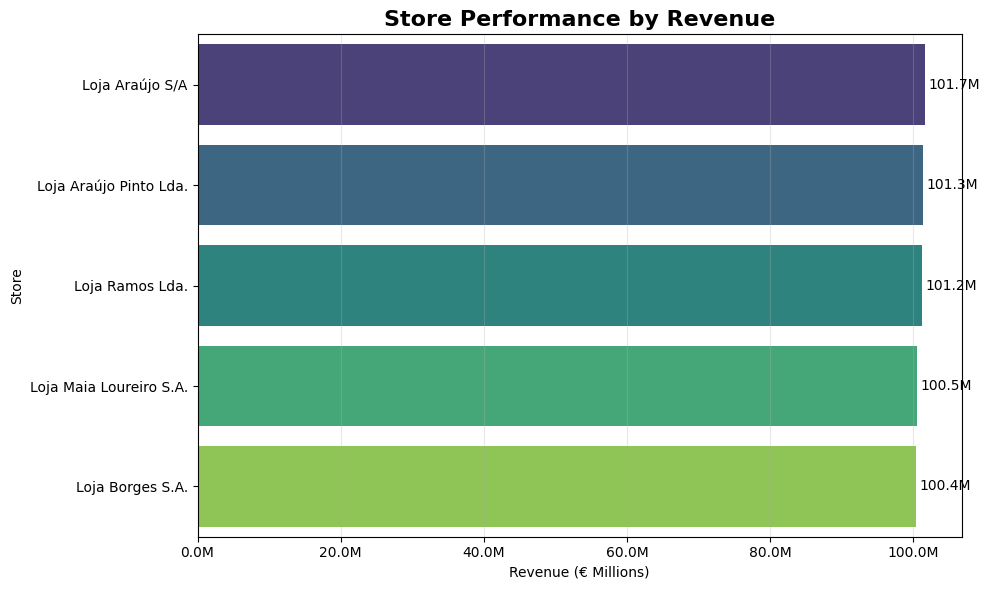

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))

sns.barplot(
    data=store_revenue,
    x="revenue",
    y="store_name",
    palette="viridis"
)

plt.title("Store Performance by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Revenue (€ Millions)")
plt.ylabel("Store")

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

for index, value in enumerate(store_revenue["revenue"]):
    plt.text(value + 500000, index, f'{value/1e6:.1f}M', va="center")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

Grafik menunjukkan bahwa performa revenue antar toko relatif merata, dengan seluruh toko menghasilkan revenue di kisaran 100 hingga 102 juta euro. Toko dengan revenue tertinggi adalah Loja Araújo S/A (sekitar 101.7M), namun selisihnya sangat kecil dibandingkan toko lainnya seperti Loja Araújo Pinto Lda. dan Loja Ramos Lda. Kondisi ini mengindikasikan bahwa kinerja penjualan antar toko cukup konsisten dan stabil, tanpa adanya ketergantungan yang signifikan pada satu toko tertentu. Hal ini menunjukkan bahwa operasional dan distribusi penjualan perusahaan kemungkinan sudah berjalan cukup seimbang di berbagai lokasi toko.

#Key Business Insights
**Profitabilitas Bisnis Sangat Tinggi**

Total revenue perusahaan mencapai sekitar €500 juta, dengan total profit sekitar €470 juta. Selisih yang relatif kecil antara revenue dan profit menunjukkan bahwa perusahaan memiliki margin keuntungan yang sangat tinggi, yang mengindikasikan bahwa biaya akuisisi produk relatif rendah dibandingkan harga jualnya.

**Penjualan Stabil Sepanjang Tahun**

Tren revenue bulanan menunjukkan bahwa penjualan relatif stabil sepanjang tahun, dengan kisaran sekitar €39M hingga €45M per bulan. Meskipun terdapat fluktuasi kecil, tidak terlihat penurunan drastis, yang menunjukkan bahwa permintaan produk cukup konsisten sepanjang periode penjualan.

**Region Centro Menjadi Kontributor Revenue Terbesar**

Analisis berdasarkan region menunjukkan bahwa Centro menghasilkan revenue tertinggi, jauh melampaui region lain seperti Alentejo dan Algarve. Hal ini menunjukkan bahwa wilayah Centro merupakan pasar utama perusahaan dan memiliki potensi besar untuk strategi ekspansi atau peningkatan investasi pemasaran.

**Beberapa Produk Menjadi Driver Utama Pendapatan**

Analisis Top 10 Products by Revenue menunjukkan bahwa beberapa produk memiliki kontribusi revenue yang jauh lebih besar dibandingkan produk lainnya. Produk seperti Modi, Adipisci, dan Hic menjadi produk unggulan perusahaan yang berperan sebagai driver utama dalam menghasilkan pendapatan.

**Kontribusi Penjualan Antar Channel Sangat Seimbang**

Penjualan melalui toko fisik (Física) dan online menunjukkan kontribusi yang hampir sama terhadap total revenue. Hal ini mengindikasikan bahwa perusahaan memiliki strategi omnichannel yang efektif, di mana pelanggan melakukan pembelian baik melalui toko fisik maupun platform online dengan tingkat kontribusi yang seimbang.

**Portofolio Produk Cukup Seimbang**

Kategori produk utama terdiri dari Calçado (sepatu) dan Roupas (pakaian) dengan kontribusi revenue yang hampir sama. Hal ini menunjukkan bahwa perusahaan memiliki portofolio produk yang seimbang tanpa ketergantungan pada satu kategori tertentu.

**Demografi Pelanggan Didominasi Usia Produktif**

Distribusi usia pelanggan menunjukkan bahwa rata-rata usia pelanggan sekitar 44.5 tahun, dengan sebagian besar pelanggan berada pada kelompok usia dewasa dan usia produktif. Hal ini menunjukkan bahwa produk perusahaan menarik bagi konsumen dengan daya beli yang relatif stabil.

**Performa Penjualan Antar Toko Relatif Konsisten**

Analisis performa toko menunjukkan bahwa seluruh toko menghasilkan revenue di kisaran €100M, dengan perbedaan yang sangat kecil antar toko. Hal ini menunjukkan bahwa operasional bisnis dan distribusi penjualan perusahaan berjalan cukup merata di seluruh lokasi toko.

In [ ]:
df["revenue"] = df["revenue"].astype(int)
df["profit"] = df["profit"].astype(int)

In [ ]:
df["revenue"] = df["revenue"].astype(int)
df["profit"] = df["profit"].astype(int)

In [ ]:
len(df)

20000

In [ ]:
df.to_csv("retail_sales.csv", index=False)